https://ryuzyproject.tistory.com/105

1. Segmentation
Segmentation은 컴퓨터 비전에서 이미지나 영상을 픽셀 단위로 분할하여 각 영역이 무엇을 나타내는지 구분하는 기술입니다.

이는 크게 Semantic Segmentation과 Instance Segmentation으로 나뉘는데, Semantic Segmentation은 같은 종류의 객체를 동일한 클래스로 분류하는 반면, Instance Segmentation은 같은 클래스 내에서도 개별 객체를 구분합니다.

이를 통해 의료 영상 분석, 자율주행, 위성 이미지 처리 등 다양한 분야에서 정밀한 객체 인식을 수행할 수 있습니다. Segmentation 모델로는 U-Net, DeepLab, Mask R-CNN 등이 널리 사용됩니다.

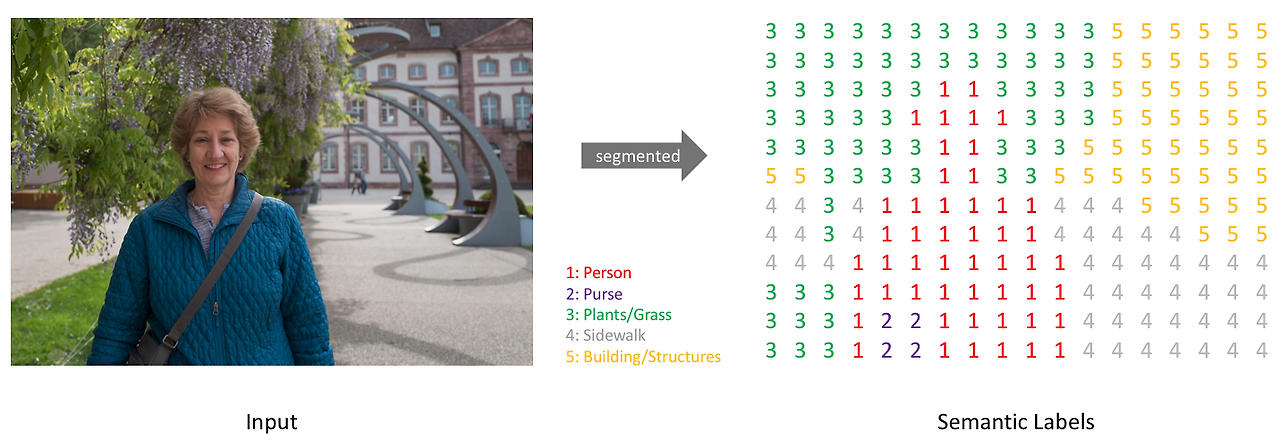

In [4]:
from pathlib import Path

s_dir = Path() / "data" / "starbucks_3_team"
s_dir.exists()

False

In [5]:
from pathlib import Path

s_dir = Path() / "data" / "starbucks_3_team"
s_dir.exists()
# from icrawler.builtin import BingImageCrawler
#
# crawler = BingImageCrawler(
#     storage={
#         "root_dir": str(s_dir)
#     }
# )
#
# crawler.crawl(
#     keyword='"Starbucks" logo',
#     filters={
#         "type": "clipart",
#         "size": "large",
#     },
#     max_num=30
# )

False

In [6]:
from ddgs import DDGS

results = DDGS().images(
    query="starbucks storefront sign",
    region="us-en",
    safesearch="moderate",
    max_results=20,
)

for result in results[:5]:
    print(result["image"])



https://static.vecteezy.com/system/resources/previews/023/440/506/large_2x/starbucks-cofee-storefront-sign-with-logo-close-up-vancouver-bc-canada-april-29-2023-free-photo.JPG
https://www.alamy.com/aggregator-api/download?url=https://c8.alamy.com/comp/2JWK6K8/starbucks-coffee-sign-at-storefront-starbucks-locations-serve-worldwide-hot-and-cold-drinks-all-sorts-of-halifax-nova-scotia-canada-aug-2022-2JWK6K8.jpg
https://c8.alamy.com/comp/3CHDDBT/provo-utah-usa-september-1-2025-a-modern-starbucks-storefront-features-bold-signage-and-clean-architectural-lines-beneath-partly-cloudy-skies-3CHDDBT.jpg
https://media.istockphoto.com/id/1433487461/photo/starbucks-coffee-storefront-sign.jpg?s=612x612&w=is&k=20&c=LmiBs23GIZgKZWZSw22sx1tuIkH8rymwRhi0FIWARAo=
https://thumbs.dreamstime.com/b/starbucks-storefront-entrance-sign-illuminated-logo-signage-above-glass-coffee-shop-open-doors-reveal-menu-boards-417282879.jpg


In [7]:
print(Path("data/starbucks_dataset").resolve())

C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_dataset


In [8]:
from pathlib import Path
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
import random
import shutil

import requests
from PIL import Image
import imagehash
from ddgs import DDGS


# ============================================================
# 설정
# ============================================================

# 키워드별 원본 이미지가 저장되는 위치
BASE_DIR = Path("data/starbucks_dataset")

# 최종적으로 모든 이미지를 섞어서 병합하는 위치
MERGED_DIR = Path("data/starbucks_merged")


# 카테고리별 최종적으로 얻고 싶은 이미지 개수
PER_KEYWORD = 75

# 다운로드 후보는 실패/중복을 고려해서 더 많이 검색
CANDIDATE_MULTIPLIER = 5

# 동시에 다운로드하는 Thread 수
MAX_WORKERS = 8

# 너무 작은 이미지 제거 기준
MIN_WIDTH = 200
MIN_HEIGHT = 200

# pHash distance
# 작을수록 중복 판정이 엄격함
PHASH_THRESHOLD = 2

# shuffle 재현성을 위한 seed
RANDOM_SEED = 42

# 이전 실행 결과를 지우고 새로 받을지 여부
RESET_RAW_DATA = True


HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/152.0 Safari/537.36"
    )
}


# ============================================================
# 검색 키워드
# ============================================================
keyword_groups = {
    # "storefront": "starbucks storefront",
    # "storefront_city": "starbucks storefront city street",
    # "storefront_korea": "starbucks store korea exterior",
    #
    # "sign": "starbucks outdoor sign",
    # "sign_close": "starbucks sign close up",
    # "sign_far": "starbucks sign far away",
    # "sign_side": "starbucks sign side view",
    #
    # "night": "starbucks store at night",
    # "night_sign": "starbucks illuminated sign night",
    #
    # "cup": "starbucks cup logo",
    # "cup_table": "starbucks cup on table",
    # "cup_hand": "starbucks cup in hand",
    #
    # "window": "starbucks logo window",
    # "interior": "starbucks cafe interior logo",
    #
    # "street": "starbucks street view",
    # "mall": "starbucks mall store",
    #
    # "sticker": "starbucks sticker",
    # "keyring": "starbucks key ring logo text"
    "tumbler": "starbucks tumbler logo",
    "merchandise": "starbucks merchandise logo",
    "drive_thru": "starbucks drive thru sign",
    "paper_bag": "starbucks paper bag logo",
    "food_package": "starbucks food packaging logo",
}

# ============================================================
# 공유 상태
# ============================================================

# 전체 카테고리에서 이미 저장된 이미지들의 pHash
saved_hashes = []

# 여러 Thread가 동시에 saved_hashes / count를
# 수정하지 못하도록 보호
state_lock = Lock()


# ============================================================
# 이미지 유사도 검사
# ============================================================

def is_duplicate(current_hash):
    """
    이미 저장된 이미지와 pHash distance를 비교한다.

    return
        True  : 너무 비슷한 이미지 존재
        False : 새로운 이미지
    """

    for old_hash in saved_hashes:

        distance = current_hash - old_hash

        if distance <= PHASH_THRESHOLD:
            return True

    return False


# ============================================================
# 이미지 다운로드
# ============================================================

def fetch_image(url):
    """
    URL에서 이미지를 다운로드하고 검증한다.

    return:
        성공 -> PIL.Image
        실패 -> None
    """

    try:

        response = requests.get(
            url,
            headers=HEADERS,
            timeout=10
        )

        if response.status_code != 200:
            return None


        # 이미지가 아닌 HTML 등이 내려오는 경우 제거
        content_type = response.headers.get(
            "Content-Type",
            ""
        )

        if "image" not in content_type.lower():
            return None


        img = Image.open(
            BytesIO(response.content)
        )

        # 실제 데이터를 읽어서 깨진 이미지 확인
        img.load()


        # 너무 작은 이미지 제거
        if (
            img.width < MIN_WIDTH
            or img.height < MIN_HEIGHT
        ):
            return None


        # JPG 저장을 위해 RGB 변환
        img = img.convert("RGB")

        return img


    except Exception:
        return None


# ============================================================
# 하나의 이미지 다운로드 + 중복 확인 + 저장
# ============================================================

def download_and_save(
    url,
    category_dir,
    category_state
):
    """
    멀티스레드에서 실행되는 함수.

    네트워크 다운로드는 병렬로 처리하고,
    pHash 검사 및 파일 번호 할당은 Lock으로 보호한다.
    """

    # ----------------------------
    # 이미지 다운로드
    # ----------------------------

    img = fetch_image(url)

    if img is None:
        return None


    # ----------------------------
    # pHash 계산
    # ----------------------------

    try:
        current_hash = imagehash.phash(img)

    except Exception:
        return None


    # ----------------------------
    # 공유 데이터 접근
    # ----------------------------

    with state_lock:

        # 이미 목표 개수를 채웠으면 종료
        if category_state["count"] >= PER_KEYWORD:
            return None


        # 중복 이미지 확인
        if is_duplicate(current_hash):
            return None


        # 저장될 번호
        index = category_state["count"]

        save_path = (
            category_dir
            / f"{index:04d}.jpg"
        )


        # ----------------------------
        # 이미지 저장
        # ----------------------------

        try:

            img.save(
                save_path,
                format="JPEG",
                quality=95
            )

        except Exception:
            return None


        # 정상 저장된 이미지의 hash만 추가
        saved_hashes.append(current_hash)

        category_state["count"] += 1


    return save_path


# ============================================================
# 하나의 카테고리 이미지 수집
# ============================================================

def crawl_category(
    category,
    keyword
):

    category_dir = BASE_DIR / category

    category_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    print()
    print("=" * 70)
    print(f"카테고리 : {category}")
    print(f"검색어   : {keyword}")
    print(f"목표     : {PER_KEYWORD}장")
    print("=" * 70)


    # --------------------------------------------------------
    # 이미지 검색
    # --------------------------------------------------------

    candidate_num = (
        PER_KEYWORD
        * CANDIDATE_MULTIPLIER
    )


    try:

        results = DDGS().images(
            query=keyword,
            region="us-en",
            safesearch="moderate",
            max_results=candidate_num
        )

    except Exception as e:

        print(
            f"[검색 실패] {category}: {e}"
        )

        return


    # URL만 추출
    urls = [
        result["image"]
        for result in results
        if result.get("image")
    ]


    print(
        f"검색 후보: {len(urls)}개"
    )


    # 카테고리 내부 저장 개수
    category_state = {
        "count": 0
    }


    # --------------------------------------------------------
    # 멀티스레드 다운로드
    # --------------------------------------------------------

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:


        futures = [

            executor.submit(
                download_and_save,
                url,
                category_dir,
                category_state
            )

            for url in urls
        ]


        for future in as_completed(futures):

            try:

                save_path = future.result()

                if save_path is not None:

                    print(
                        f"[저장] {save_path}"
                    )

            except Exception as e:

                print(
                    f"[Thread 오류] {e}"
                )


    print()

    print(
        f"{category}: "
        f"{category_state['count']}장 저장 완료"
    )


# ============================================================
# 전체 이미지 수집
# ============================================================

def crawl_images():

    # 이전 실행 결과 초기화
    if RESET_RAW_DATA:

        if BASE_DIR.exists():
            shutil.rmtree(BASE_DIR)


    BASE_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


    print()
    print("#" * 70)
    print("Starbucks 이미지 수집 시작")
    print("#" * 70)


    for category, keyword in keyword_groups.items():

        crawl_category(
            category,
            keyword
        )


    print()
    print("#" * 70)
    print("이미지 수집 완료")
    print("#" * 70)


# ============================================================
# 카테고리별 이미지 개수 출력
# ============================================================

def print_dataset_info():

    print()
    print("=" * 70)
    print("카테고리별 이미지 개수")
    print("=" * 70)


    total = 0


    for category in keyword_groups:

        category_dir = (
            BASE_DIR
            / category
        )


        files = list(
            category_dir.glob("*.jpg")
        )


        count = len(files)

        total += count


        print(
            f"{category:15s}: "
            f"{count:4d}장"
        )


    print("-" * 70)

    print(
        f"{'TOTAL':15s}: "
        f"{total:4d}장"
    )


# ============================================================
# 모든 이미지 Shuffle + 병합
# ============================================================

def merge_and_shuffle():

    # 모든 하위 폴더의 JPG 가져오기
    image_paths = list(
        BASE_DIR.rglob("*.jpg")
    )


    print()
    print("=" * 70)
    print("이미지 병합")
    print("=" * 70)

    print(
        f"병합 대상: {len(image_paths)}장"
    )


    # --------------------------------------------------------
    # Shuffle
    # --------------------------------------------------------

    rng = random.Random(
        RANDOM_SEED
    )

    rng.shuffle(
        image_paths
    )


    # --------------------------------------------------------
    # 기존 merged 폴더 제거
    # --------------------------------------------------------

    if MERGED_DIR.exists():

        shutil.rmtree(
            MERGED_DIR
        )


    MERGED_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # 새로운 이름으로 복사
    # --------------------------------------------------------

    for index, src_path in enumerate(
        image_paths,
        start=1
    ):

        dst_path = (
            MERGED_DIR
            / f"{index:06d}.jpg"
        )


        shutil.copy2(
            src_path,
            dst_path
        )


    print()
    print("병합 완료")

    print(
        f"저장 위치 : {MERGED_DIR}"
    )

    print(
        f"총 이미지 : {len(image_paths)}장"
    )


# ============================================================
# 실행
# ============================================================

def main():

    # 1.
    # 검색 + 멀티스레드 다운로드
    # crawl_images()


    # 2.
    # 데이터 개수 확인
    # print_dataset_info()


    # 3.
    # 전체 이미지 shuffle + 병합
    merge_and_shuffle()


# main()

# **2. 스타벅스 데이터셋**


In [9]:
import json
import random
import shutil
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import ultralytics
import yaml

from ultralytics import YOLO

In [10]:
PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "data"

SOURCE_DIR = DATA_ROOT / "starbucks"
YOLO_ROOT = DATA_ROOT / "starbucks_yolo"
COCO_JSON = SOURCE_DIR / "instances_default.json"

DATA_ROOT.resolve(), DATA_ROOT.exists()

print("PROJECT_ROOT", PROJECT_ROOT)
print("SOURCE_DIR", SOURCE_DIR)
print("YOLO_ROOT", YOLO_ROOT)
print("COCO_JSON", COCO_JSON)

PROJECT_ROOT C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons
SOURCE_DIR C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks
YOLO_ROOT C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo
COCO_JSON C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks\instances_default.json


In [11]:
COCO_JSON.exists()

True

# 2. 스타벅스 데이터셋

### COCO JSON
- images: 이미지 ID, 파일명, width, height
- annotations: 객체의 category, polygon, bbox 등
- categories: 클래스 ID와 이름

In [12]:
with COCO_JSON.open("r", encoding="utf-8") as f:
    coco_data = json.load(f)

coco_data

{'licenses': [{'name': '', 'id': 0, 'url': ''}],
 'info': {'contributor': '',
  'date_created': '',
  'description': '',
  'url': '',
  'version': '',
  'year': ''},
 'categories': [{'id': 1, 'name': 'logo', 'supercategory': ''},
  {'id': 2, 'name': 'text', 'supercategory': ''}],
 'images': [{'id': 1,
   'width': 1024,
   'height': 682,
   'file_name': '000001.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 2,
   'width': 885,
   'height': 960,
   'file_name': '000002.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 3,
   'width': 1600,
   'height': 1155,
   'file_name': '000003.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 4,
   'width': 1300,
   'height': 956,
   'file_name': '000004.jpg',
   'license': 0,
   'flickr_url': '',
   'coco_url': '',
   'date_captured': 0},
  {'id': 5,
   'width': 900,
   'height': 1200,
   'file_name': '000005.j

In [13]:
# category ID가 반드시 연속이라는 보장이 없음
categories = sorted(coco_data["categories"], key=lambda x: x["id"])
categories

COCO_ID_TO_YOLO_ID = {
    category['id']: yolo_id for yolo_id, category in enumerate(categories)
}

CLASS_NAMES = [category["name"] for category in categories]

print("이미지 수:", len(coco_data["images"]))
print("Annotation 수:", len(coco_data["annotations"]))
print("클래스:", CLASS_NAMES)
print("ID 매핑:", COCO_ID_TO_YOLO_ID)

이미지 수: 612
Annotation 수: 1296
클래스: ['logo', 'text']
ID 매핑: {1: 0, 2: 1}


ㅠ### 이미지와 Annotation 확인
- JSON에 등록된 이미지가 실제 폴더에 모두 존재하는지 확인
- 클래스별 annotation 수를 확인하면 특정 클래스가 지나치게 적은지도 화ㅗㄱ인할 수 있음

In [38]:
image_info_by_id = {
    image_info["id"]: image_info
    for image_info in coco_data["images"]
}

# 순회하면서 이미지에 대해서 객체의 segmentation 리스트 넣어주기
# {
#     image_id: {
#         1: list([]),
#         2: list([])
#     }
# }
image_segmentation_list = {}
for annot in coco_data["annotations"]:
    # 객체에 이미지 자체가 등록되어있지 않으면 딕셔너리 넣어주기
    if image_segmentation_list.get(annot.get("image_id")) is None:
        # coco의 경우에는 id가 1과 2로 나뉘어져있음
        image_segmentation_list[annot.get("image_id")] = { 1: [], 2: []}

    # 세그멘테이션 넣어주기
    image_segmentation_list[annot.get("image_id")][annot.get("category_id")] = annot.get("segmentation")

# image_info_by_id

missing_images = []

for image_info in coco_data["images"]:
    image_path = SOURCE_DIR / image_info["file_name"]
    if not image_path.exists():
        missing_images.append(image_info["file_name"])

print("누락 이미지 수:", len(missing_images))
class_counts = (
    Counter(
        COCO_ID_TO_YOLO_ID[ann["category_id"]]
        for ann in coco_data["annotations"]
        if ann["category_id"] in COCO_ID_TO_YOLO_ID
    )
)
for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"{class_id}: {class_name} > {class_counts[class_id]} annotations")

누락 이미지 수: 0
0: logo > 933 annotations
1: text > 363 annotations


In [15]:
image_segmentation_list

{1: {1: [[337.04,
    112.81,
    306.78,
    125.08,
    286.34,
    141.43,
    269.17,
    161.06,
    253.63,
    185.59,
    242.18,
    219.12,
    235.64,
    246.92,
    236.46,
    270.64,
    238.91,
    303.35,
    243.0,
    331.97,
    251.18,
    358.14,
    263.44,
    383.49,
    274.89,
    403.93,
    291.25,
    429.28,
    303.51,
    448.09,
    321.5,
    475.89,
    337.86,
    493.88,
    371.38,
    524.14,
    404.91,
    544.58,
    428.63,
    555.21,
    453.98,
    564.21,
    478.51,
    573.2,
    509.58,
    577.29,
    539.84,
    575.66,
    570.1,
    565.84,
    592.99,
    556.03,
    612.62,
    539.68,
    631.43,
    521.69,
    647.78,
    492.25,
    658.41,
    461.99,
    661.68,
    430.1,
    661.68,
    398.21,
    658.41,
    363.86,
    650.24,
    327.06,
    635.52,
    290.26,
    618.34,
    260.01,
    599.54,
    230.57,
    571.73,
    199.49,
    543.11,
    172.51,
    518.58,
    153.7,
    494.86,
    137.35,
    472.79,
    

### COCO Polygon Annotation 시각화
```
[x1, y1, x2, y2, x3, y3, ...]
```

최소 3개의 점을 연결해서 객체 외곽을 표현

In [16]:
def load_rgb_image(image_path: Path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"이미지를 읽을 수 없습니다: {image_path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

In [17]:
import numpy as np

# 세그멘테이션 전용 자료 만들어주기
image_segmentation_list = {}
for annot in coco_data["annotations"]:
    # 객체에 이미지 자체가 등록되어있지 않으면 딕셔너리 넣어주기
    if image_segmentation_list.get(annot.get("image_id")) is None:
        # coco의 경우에는 id가 1과 2로 나뉘어져있음
        image_segmentation_list[annot.get("image_id")] = { 1: [], 2: []}

    # 세그멘테이션 넣어주기
    image_segmentation_list[annot.get("image_id")][annot.get("category_id")] += annot.get("segmentation")

COLOR_CAT_COCO = {
    # 로고
    1: (0, 0, 255),
    # 텍스트
    2: (255, 2)
}

def visualize_coco_annotation(image_id: int):
    image_info = image_info_by_id.get(image_id)
    if image_info is None:
        raise ValueError(f"존재하지 않는 image_id입니다: {image_id}")

    image = load_rgb_image((SOURCE_DIR / image_info["file_name"])).copy()

    # print(len(coco_data["annotations"][image_id]["segmentation"]))
    # 1번 라벨 뽑아주기
    for cat in [1, 2]:
        # cat는 1, 2 순서이고, CLASS_NAME는 [logo, text]
        name = CLASS_NAMES[COCO_ID_TO_YOLO_ID[cat]]

        # 카테고리 전체 세그멘테이션을 통해 그려주기
        for seg in image_segmentation_list.get(image_id).get(cat):
            # print(seg)
            # seg 형태가 float라서 int로 변환해주기

            # 이렇게 해도 안됨
            # for i in range(seg):
            #     seg[i] = int(round(seg[i], 0))
            print(seg)

            # numpy로 쉽게 변환 ([x, y] 리스트로 묶어주기
            new_seg = np.array(seg, dtype=np.int32).reshape(-1, 2)
            # image는 numpy RGB (H, W, 3) 배열 -> 그려주기

            # 그려주기
            cv2.polylines(image, [new_seg], True, COLOR_CAT_COCO[cat], 4)

            # 좌상단 구하기
            x_min, y_min = np.min(new_seg, axis=0)

            # 이름도 올려주기
            cv2.putText(image, name, (x_min, y_min), cv2.FONT_HERSHEY_SIMPLEX, 0.7, COLOR_CAT_COCO[cat], 4)

    # coco 어노테이션에서 좌표값들을 가져와야함
    # 이미지 출력 전에 리사이징 한번 해주기
    img_w = image.shape[1] # width
    img_h = image.shape[0] # height

    # 비율 맞춰주기
    max_ = 1200

    if img_w > max_ or img_h > max_:
        # 둘중에 더 큰것에 대한 나눠야하는 비율
        times_ratio = max_ / max(img_w, img_h)


        # 리사이징 한 이미지
        image = cv2.resize(image, (int(img_w*times_ratio), int(img_h*times_ratio)))
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"COCO Annotation - {image_info["file_name"]}")
    plt.show()
    # cv2.imshow("visualize_coco_annot", image)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

In [18]:
# 강사님 코드
def visualize_coco_annotation(image_id: int):
    image_info = image_info_by_id.get(image_id)
    if image_info is None:
        raise ValueError(f'존재하지 않는 image_id입니다: {image_id}')

    image = load_rgb_image(SOURCE_DIR / image_info['file_name']).copy()

    for ann in coco_data["annotations"]:
        if ann['image_id'] != image_id:
            continue

        class_id = COCO_ID_TO_YOLO_ID[ann['category_id']]
        class_name = CLASS_NAMES[class_id]

        for polygon in ann.get("segmentation", []):
            if not isinstance(polygon, list) or len(polygon) < 6:
                continue

            points = np.array(polygon, dtype=np.float32).reshape(-1, 2).astype(np.int32)

            cv2.polylines(image, [points], True, (0, 255, 0), 2)

            x, y = points[0]
            cv2.putText(image, class_name, (int(x), max(20, int(y) - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"COCO Annotation - {image_info['file_name']}")
    plt.show()

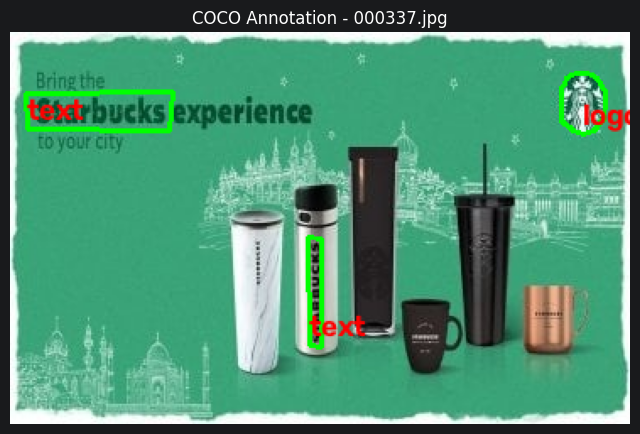

In [19]:
# for i in range(1, 400):
#     visualize_coco_annotation(i)
visualize_coco_annotation(300)


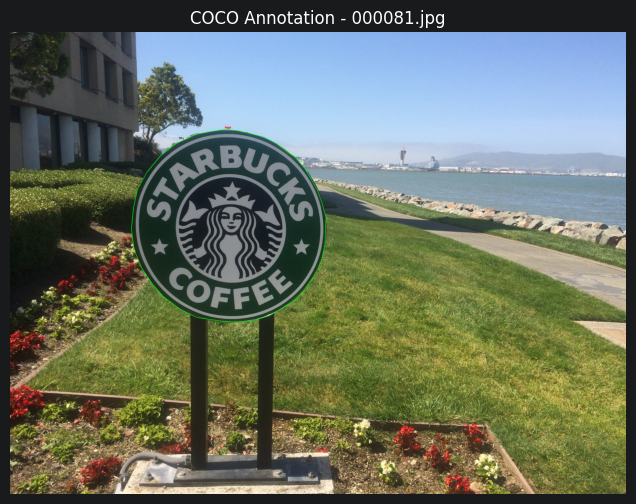

In [20]:
visualize_coco_annotation(81)


In [21]:
coco_data["annotations"][1].keys()

dict_keys(['id', 'image_id', 'category_id', 'segmentation', 'area', 'bbox', 'iscrowd', 'attributes'])

### COCO Yolo Segmentation 변환

YOLO Segmentation 라벨
```
class_id x1 y1 x2 y2 x3 y3 ...
```
좌표는 픽셀 값이 아니라 0 ~ 1 사이로 정규화

- x_norm = x / image_width
- y_norm = y / image_height

In [22]:
def coco_polygon_to_yolo_line(class_id, polygon, image_width, image_height):
    if not isinstance(polygon, list) or len(polygon) < 6:
        return None

    if len(polygon) % 2 != 0:
        return None

    normalized_values = []

    for i in range(0, len(polygon), 2):
        x = polygon[i]
        y = polygon[i + 1]
        x_norm = x / image_width
        y_norm = y / image_height

        x_norm = min(max(x_norm, 0.0), 1.0)
        y_norm = min(max(y_norm, 0.0), 1.0)

        normalized_values.extend([x_norm, y_norm])

    coordinates = " ".join(f'{value:.6f}' for value in normalized_values)
    return f'{class_id} {coordinates}'

# train / val / test 분할

In [23]:
SEED = 2026
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2

random.seed(SEED)

all_images = [image_info for image_info in coco_data["images"]
              if (SOURCE_DIR / image_info["file_name"]).exists()]

random.shuffle(all_images)

num_images = len(all_images)
num_train = int(num_images * TRAIN_RATIO)
num_val = int(num_images * VAL_RATIO)

train_images =  all_images[:num_train]
val_images = all_images[num_train: num_train+num_val]
test_images = all_images[num_train+num_val:]

print("전체:", num_images)
print("train:", len(train_images))
print("val:", len(val_images))
print("test:", len(test_images))



전체: 612
train: 367
val: 122
test: 123


# YOLO 폴더 구조 생성하기
- YOLO의 명확한 구조는 이미지와 라벨을 분리하는 방식
- 예) `images/train/starbucks/11.jpg` > `labels/train/starbucks/11.txt` 로 매핑됨

In [24]:
import shutil

def prepare_yolo_split(split_name, split_images):
    image_output_dir = YOLO_ROOT / "images" / split_name
    label_output_dir = YOLO_ROOT / "labels" / split_name

    image_output_dir.mkdir(parents=True, exist_ok=True)
    label_output_dir.mkdir(parents=True, exist_ok=True)

    # 재실행할 때 과거 파일이 남아 섞이는 것을 방지하기 위한 코드
    for old_file in image_output_dir.iterdir():
        if old_file.is_file():
            old_file.unlink()

    for old_file in label_output_dir.iterdir():
        if old_file.is_file():
            old_file.unlink()

    annotations_by_image = {}

    for ann in coco_data["annotations"]:
        annotations_by_image.setdefault(ann["image_id"], []).append(ann)

    # 분할된 이미지 경로 리스트에 대해서
    for image_info in split_images:
        image_id = image_info["id"]
        image_width = image_info["width"]
        image_height = image_info["height"]
        file_name = image_info["file_name"]

        shutil.copy2(SOURCE_DIR / file_name, image_output_dir / file_name)

        yolo_lines = []

        # 모든 이미지 id 에 대해서 순회처리해주기
        for ann in annotations_by_image.get(image_id, []):
            coco_category_id = ann["category_id"]
            if coco_category_id not in COCO_ID_TO_YOLO_ID:
                continue
            class_id = COCO_ID_TO_YOLO_ID[coco_category_id]
            segmentation = ann.get("segmentation", [])

            if not isinstance(segmentation, list):
                continue

            for polygon in segmentation:
                yolo_line = coco_polygon_to_yolo_line(class_id, polygon, image_width, image_height)

                if yolo_line is not None:
                    yolo_lines.append(yolo_line)

        label_path = label_output_dir / f"{Path(file_name).stem}.txt"
        if yolo_lines:
            label_path.write_text("\n".join(yolo_lines), encoding="utf-8")

In [25]:
prepare_yolo_split("train", train_images)
prepare_yolo_split("val", val_images)
prepare_yolo_split("test", test_images)
print("COCO > YOLO segmentation 변경 완료")

COCO > YOLO segmentation 변경 완료


### YOLO txt 라벨

In [26]:
# coco json이 아니라 변환된 yolo txt를 읽어서 폴리곤을 그려보기
# YOLO_ROOT
def visualize_yolo_annotation(image_id: int):
    # 우선 image_id 에 대한 폴더 위치 찾기
    file_name = image_info_by_id[image_id].get("file_name")

    # 이미지 파일이 실제로 존재하는 위치
    image_path = None
    # 라벨 파일이 실제로 존재하는 위치
    label_path = None

    # 각 폴더를 순회하면서 파일 존재하는 위치 찾아주기
    for folder in ["train", "val", "test"]:
        if (YOLO_ROOT / "images" / folder / file_name).exists():
            image_path = YOLO_ROOT / "images" / folder / file_name
            # 라벨 위치 잡아주기
            label_path = YOLO_ROOT / "labels" / folder / ".".join(file_name.split(".")[:-1] + ["txt"])

    if None in (image_path, label_path):
        raise Exception(f"path not exists: image_path:\n{image_path}\nlabel_path:\n{label_path}")


    # 반정규화용 이미지 사이즈 가져와주기
    img_w = image_info_by_id[image_id].get("width")
    img_h = image_info_by_id[image_id].get("height")

    # 라벨 읽어와주기
    content = label_path.read_text(encoding="utf-8")

    # 이미지 읽어와주기
    image = cv2.imread(str(image_path))

    # print(content)
    # # 라벨 읽어서 세그멘테이션 데이터셋으로 만들어주기
    annotations = {}
    for row in content.split("\n"):
        cat, segs = int(row.split(" ")[0]), row.split(" ")[1:]
        segs = (np.array(segs, dtype=np.float32).reshape(-1, 2) * np.array([img_w, img_h])).astype(np.int32)

        # print(cat, segs.shape)
        # print(segs)

        x_min, y_min = segs.min(axis=0)



        image = cv2.polylines(image, [segs], True, (255, 0, 0), 4)

        image = cv2.putText(image, CLASS_NAMES[cat], (x_min, y_min), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 4)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"COCO Annotation - {image_info['file_name']}")
    plt.show()


In [37]:
def visualize_yolo_label(split_name, image_name):
    image_path = YOLO_ROOT / "images" / split_name / image_name
    label_path = YOLO_ROOT / "labels" / split_name / f"{Path(image_name).stem}.txt"

    image = load_rgb_image(image_path).copy()
    height, width = image.shape[:2]

    if not label_path.exists():
        raise FileNotFoundError(f'라벨이 없습니다: {label_path}')

    for line in label_path.read_text(encoding="utf-8").splitlines():
        values = line.split()
        class_id = int(values[0])
        class_name = CLASS_NAMES[class_id]

        points = np.array(list(map(float, values[1:])), dtype=np.float32).reshape(-1, 2)
        points[:, 0] *= width
        points[:, 1] *= height
        points = points.astype(np.int32)

        cv2.polylines(image, [points], True, (0, 255, 0), 2)



        x, y = points[0]
        cv2.putText(image, class_name, (int(x), max(20, int(y) - 5)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"COCO Annotation - {image_info['file_name']}")
        plt.show()

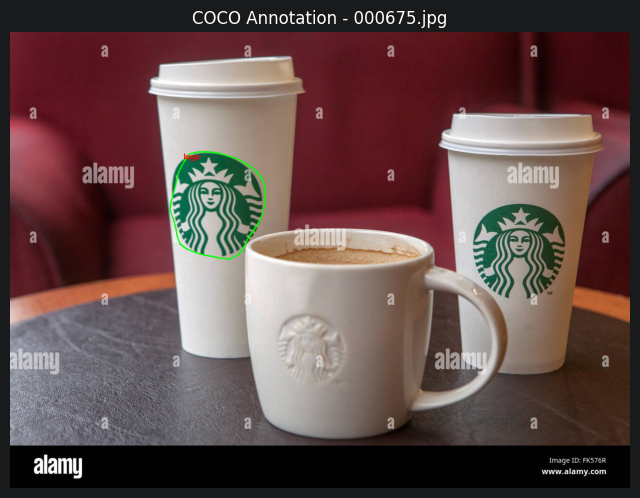

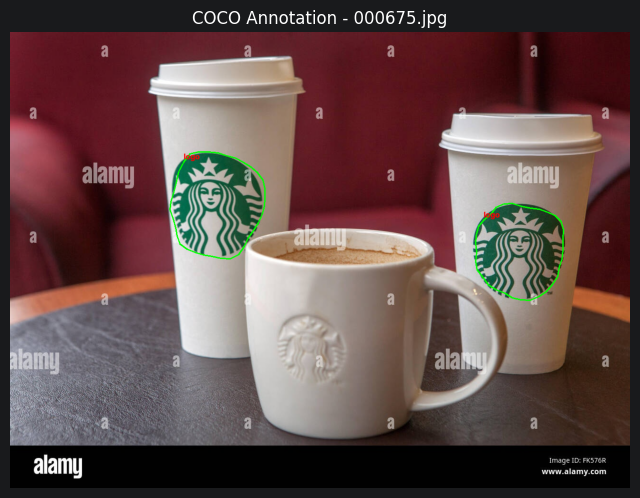

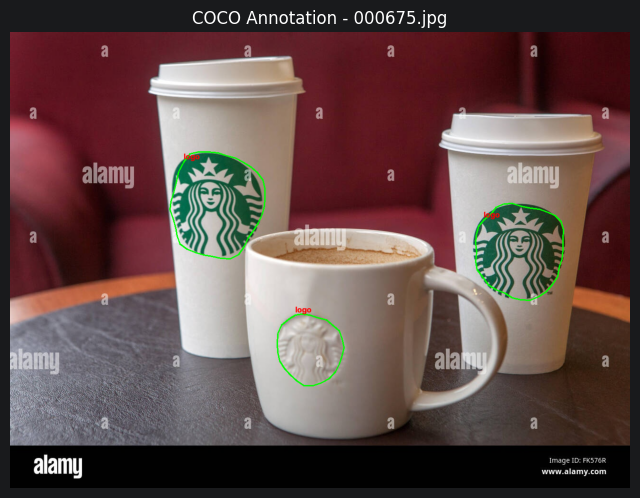

In [41]:


visualize_yolo_label("train", train_images[81]["file_name"])

In [ ]:
image_info_by_id

In [ ]:
image_info_by_id[1]

# YOLO 데이터셋 YAML 생성

In [42]:
yaml_data = {
    "path": str(YOLO_ROOT.resolve()),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        class_id: class_name for class_id, class_name in enumerate(CLASS_NAMES)
    }
}

YAML_PATH = YOLO_ROOT / "starbucks.yaml"

with YAML_PATH.open("w", encoding="utf-8") as f:
    yaml.safe_dump(yaml_data, f, allow_unicode=True, sort_keys=False)

print(YAML_PATH.read_text(encoding="utf-8"))

path: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo
train: images/train
val: images/val
test: images/test
names:
  0: logo
  1: text



# YOLO11 세그멘테이션 모델 불러오기

In [43]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cuda


In [44]:
model = YOLO("yolo11s-seg.pt")
print("Model task:", model.task)

Model task: segment


In [45]:
train_results = model.train(
    data=str(YAML_PATH),
    epochs=50,
    imgsz=640,
    batch=4,
    device=DEVICE,
    workers=0,
    seed=SEED,
    patience=20,
    name="starbucks_yolo11s_seg",
    exist_ok=True
)

New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.143  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\starbucks.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

KeyboardInterrupt: 

In [49]:
 last_w = Path(r"C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\runs\segment\starbucks_yolo11s_seg\weights\last.pt")

In [50]:
model = YOLO(last_w)
train_results = model.train(resume=True)

New https://pypi.org/project/ultralytics/8.4.146 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.143  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\starbucks.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

In [51]:
RUN_DIR = PROJECT_ROOT / "runs" / "segment" / "starbucks_yolo11s_seg"
BEST_MODEL_PATH = RUN_DIR / "weights" / "best.pt"

print("best.pt:", BEST_MODEL_PATH)

best.pt: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\runs\segment\starbucks_yolo11s_seg\weights\best.pt


In [52]:
# 일반 pretrained 모델을 쓰는게 아니라
best_model = YOLO(str(BEST_MODEL_PATH))

print("Task :", best_model.task)
print("Classes: ", best_model.names)

Task : segment
Classes:  {0: 'logo', 1: 'text'}


### Validation 성능 평가

Segmentation 모델은 Box와 Mask 성능을 따로 봄.
- metrics.box: Bounding Box 기준
- metrics.seg: Segmentation Mask 기준
- mAP 50 등은 계속 존재함.

In [53]:
metrics = best_model.val(
    data=str(YAML_PATH),
    split="val",
    imgsz=640,
    device=DEVICE
)

Ultralytics 8.4.143  Python-3.12.10 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti Laptop GPU, 12227MiB)
YOLO11s-seg summary (fused): 113 layers, 10,067,590 parameters, 0 gradients, 32.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 220.0139.7 MB/s, size: 447.0 KB)
val: Scanning C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\labels\val.cache... 121 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 122/122  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 2.7it/s 3.0s0.3ss
                   all        122        266      0.877      0.746      0.823      0.597       0.87      0.738      0.817      0.559
                  logo        108        206      0.904      0.859      0.911      0.741      0.907      0.859      0.911      0.725
                  text         46         60      

In [55]:
print("Box mAP50:", metrics.box.map50)
print("Box mAP50-95:", metrics.box.map)
print("Seg mAP50:", metrics.seg.map50)
print("Seg mAP50-95:", metrics.seg.map)

Box mAP50: 0.8230387986125255
Box mAP50-95: 0.5973226626554988
Seg mAP50: 0.816646366978139
Seg mAP50: 0.5585392816865482


### Segmentation 추론
- result.boxes.xyxy: Bounding Box 좌표
- result.boxed.cls: class ID
- result.boxes.conf: confidence score
- result.masks.xy: polygon 좌표
- result.masks.data: mask tensor

In [56]:
TEST_IMAGE_DIR = YOLO_ROOT / "images" / "test"

predict_results = best_model.predict(
    source=str(TEST_IMAGE_DIR),
    imgsz=640,
    conf=0.30,
    device=DEVICE,
    retina_masks=True,
    save=True,
    name="starbucks_yolo11s_set_predict",
    exist_ok=True
)


image 1/123 C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\images\test\000003.jpg: 480x640 1 logo, 1 text, 32.6ms
image 2/123 C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\images\test\000010.jpg: 640x416 1 logo, 40.3ms
image 3/123 C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\images\test\000012.jpg: 480x640 1 logo, 22.4ms
image 4/123 C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\images\test\000026.jpg: 288x640 4 logos, 1 text, 35.7ms
image 5/123 C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\images\test\000033.jpg: 480x640 1 logo, 1 text, 21.3ms
image 6/123 C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01

In [57]:
for result in predict_results[:3]:
    print("=" * 70)
    print("image:", result.path)

    if result.boxes is not None:
        print("classes    :", result.boxes.cls.cpu().tolist())
        print("confidence :", result.boxes.conf.cpu().tolist())
        print("boxes xyxy :")
        print(result.boxes.xyxy.cpu().numpy())

    if result.masks is not None:
        print("mask tensor shape:", tuple(result.masks.data.shape))
        print("polygon 개수     :", len(result.masks.xy))
    else:
        print("검출된 segmentation mask가 없습니다.")

image: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\images\test\000003.jpg
classes    : [0.0, 1.0]
confidence : [0.883479118347168, 0.452889621257782]
boxes xyxy :
[[     1460.5      810.85      1599.5      1041.3]
 [      611.3       572.6       653.4       865.2]]
mask tensor shape: (2, 1155, 1600)
polygon 개수     : 2
image: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\images\test\000010.jpg
classes    : [0.0]
confidence : [0.898205041885376]
boxes xyxy :
[[     440.51      751.15      632.69      984.94]]
mask tensor shape: (1, 1500, 922)
polygon 개수     : 1
image: C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_yolo\images\test\000012.jpg
classes    : [0.0]
confidence : [0.9605572819709778]
boxes xyxy :
[[     334.83       34.06      867.67       519.2]]
mask

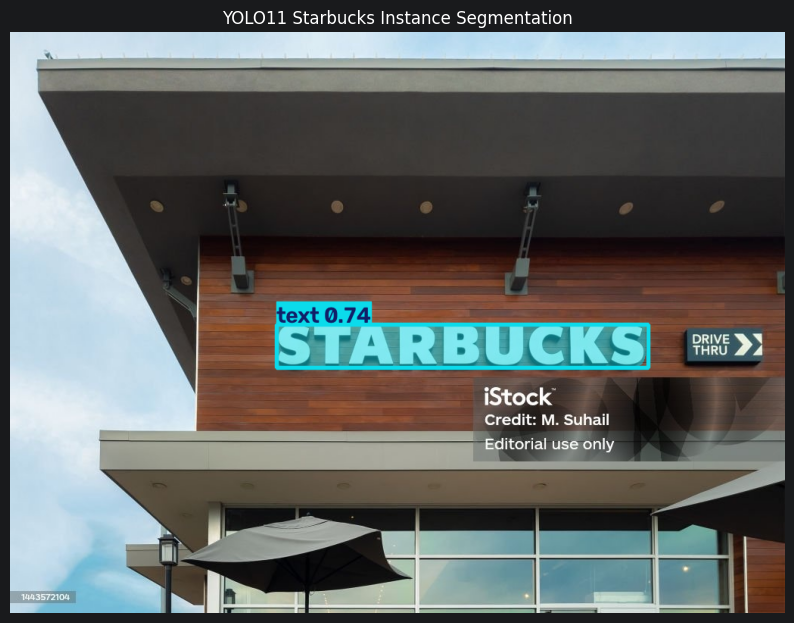

In [62]:
if not predict_results:
    raise RuntimeError("추론 결과가 없습니다.")

result = predict_results[34]

plotted_bgr = result.plot()
plotted_rgb = cv2.cvtColor(
    plotted_bgr,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(plotted_rgb)
plt.axis("off")
plt.title("YOLO11 Starbucks Instance Segmentation")
plt.show()